# Supplementary Figure S6: classifier smoothing

These cells read the included numerical results, calculate the panel summaries, and draw new figures.

## Run the notebook

This page starts with the paper's saved inputs. Run its Python cells from top to bottom to create the output shown here.

To repeat the model calculations first, use the [analysis and input guide](../../reference/figure_sources/classifier-smoothing.md). It identifies the model, data, analysis programs, and the files read by this notebook. Choose that route only if you want to recalculate those inputs.

## Imports and configuration

In [1]:
import pandas as pd

pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)

from pathlib import Path

from IPython.display import Image, display

from CytoBridge.results import (
    load_classifier_smoothing_results,
    plot_classifier_smoothing,
)
from CytoBridge.results.classifier_smoothing import (
    classifier_smoothing_statistics,
    write_classifier_smoothing_tables,
)

output_dir = Path("outputs") / "classifier_smoothing"
output_dir.mkdir(parents=True, exist_ok=True)

## Load processed results

In [2]:
results = load_classifier_smoothing_results()
display(results.metrics.head())
display(results.policy)

,dataset,k,n_heldout,balanced_accuracy,macro_f1,accuracy
0,admouse,1,17210,0.954482,0.953965,0.960604
1,admouse,5,17210,0.461769,0.462742,0.628007
2,admouse,10,17210,0.429242,0.420548,0.604474
3,admouse,20,17210,0.414375,0.396418,0.596572
4,admouse,50,17210,0.399508,0.377927,0.585764


,dataset,accuracy_best_k,formal_analysis_k,rationale
0,zebrafish,1,10,Spatially regularized tissue-domain labels; use the same k in every analysis and figure that uses these labels
1,mosta,1,10,Spatially regularized tissue-domain labels; use the same k in every analysis and figure that uses these labels
2,arista,1,10,Spatially regularized tissue-domain labels; use the same k in every analysis and figure that uses these labels
3,admouse,1,1,Heterogeneous and rare populations are strongly suppressed by larger-k smoothing; retain raw MLP labels
4,chicken_heart,1,1,Developing-heart cell types include spatially restricted populations; retain the validation-selected unsmoothed MLP labels


## Recalculate panel data

Composition s.e.m. is calculated over nine generated frames per `k`; transition s.e.m. is calculated over four fixed-cohort intervals per `k`.

In [3]:
display(results.composition)
display(results.transition)

,k,mean,sem
0,1,0.000000,0.000000
1,5,4.630056,0.700403
2,10,7.649367,1.347172
3,20,10.384740,2.045209
4,50,14.462290,2.699662


,k,mean,sem
0,1,87.477798,4.480284
1,5,88.321492,4.741916
2,10,87.522202,5.231690
3,20,87.655417,5.331310
4,50,88.277087,5.189116


## Render and save the figure

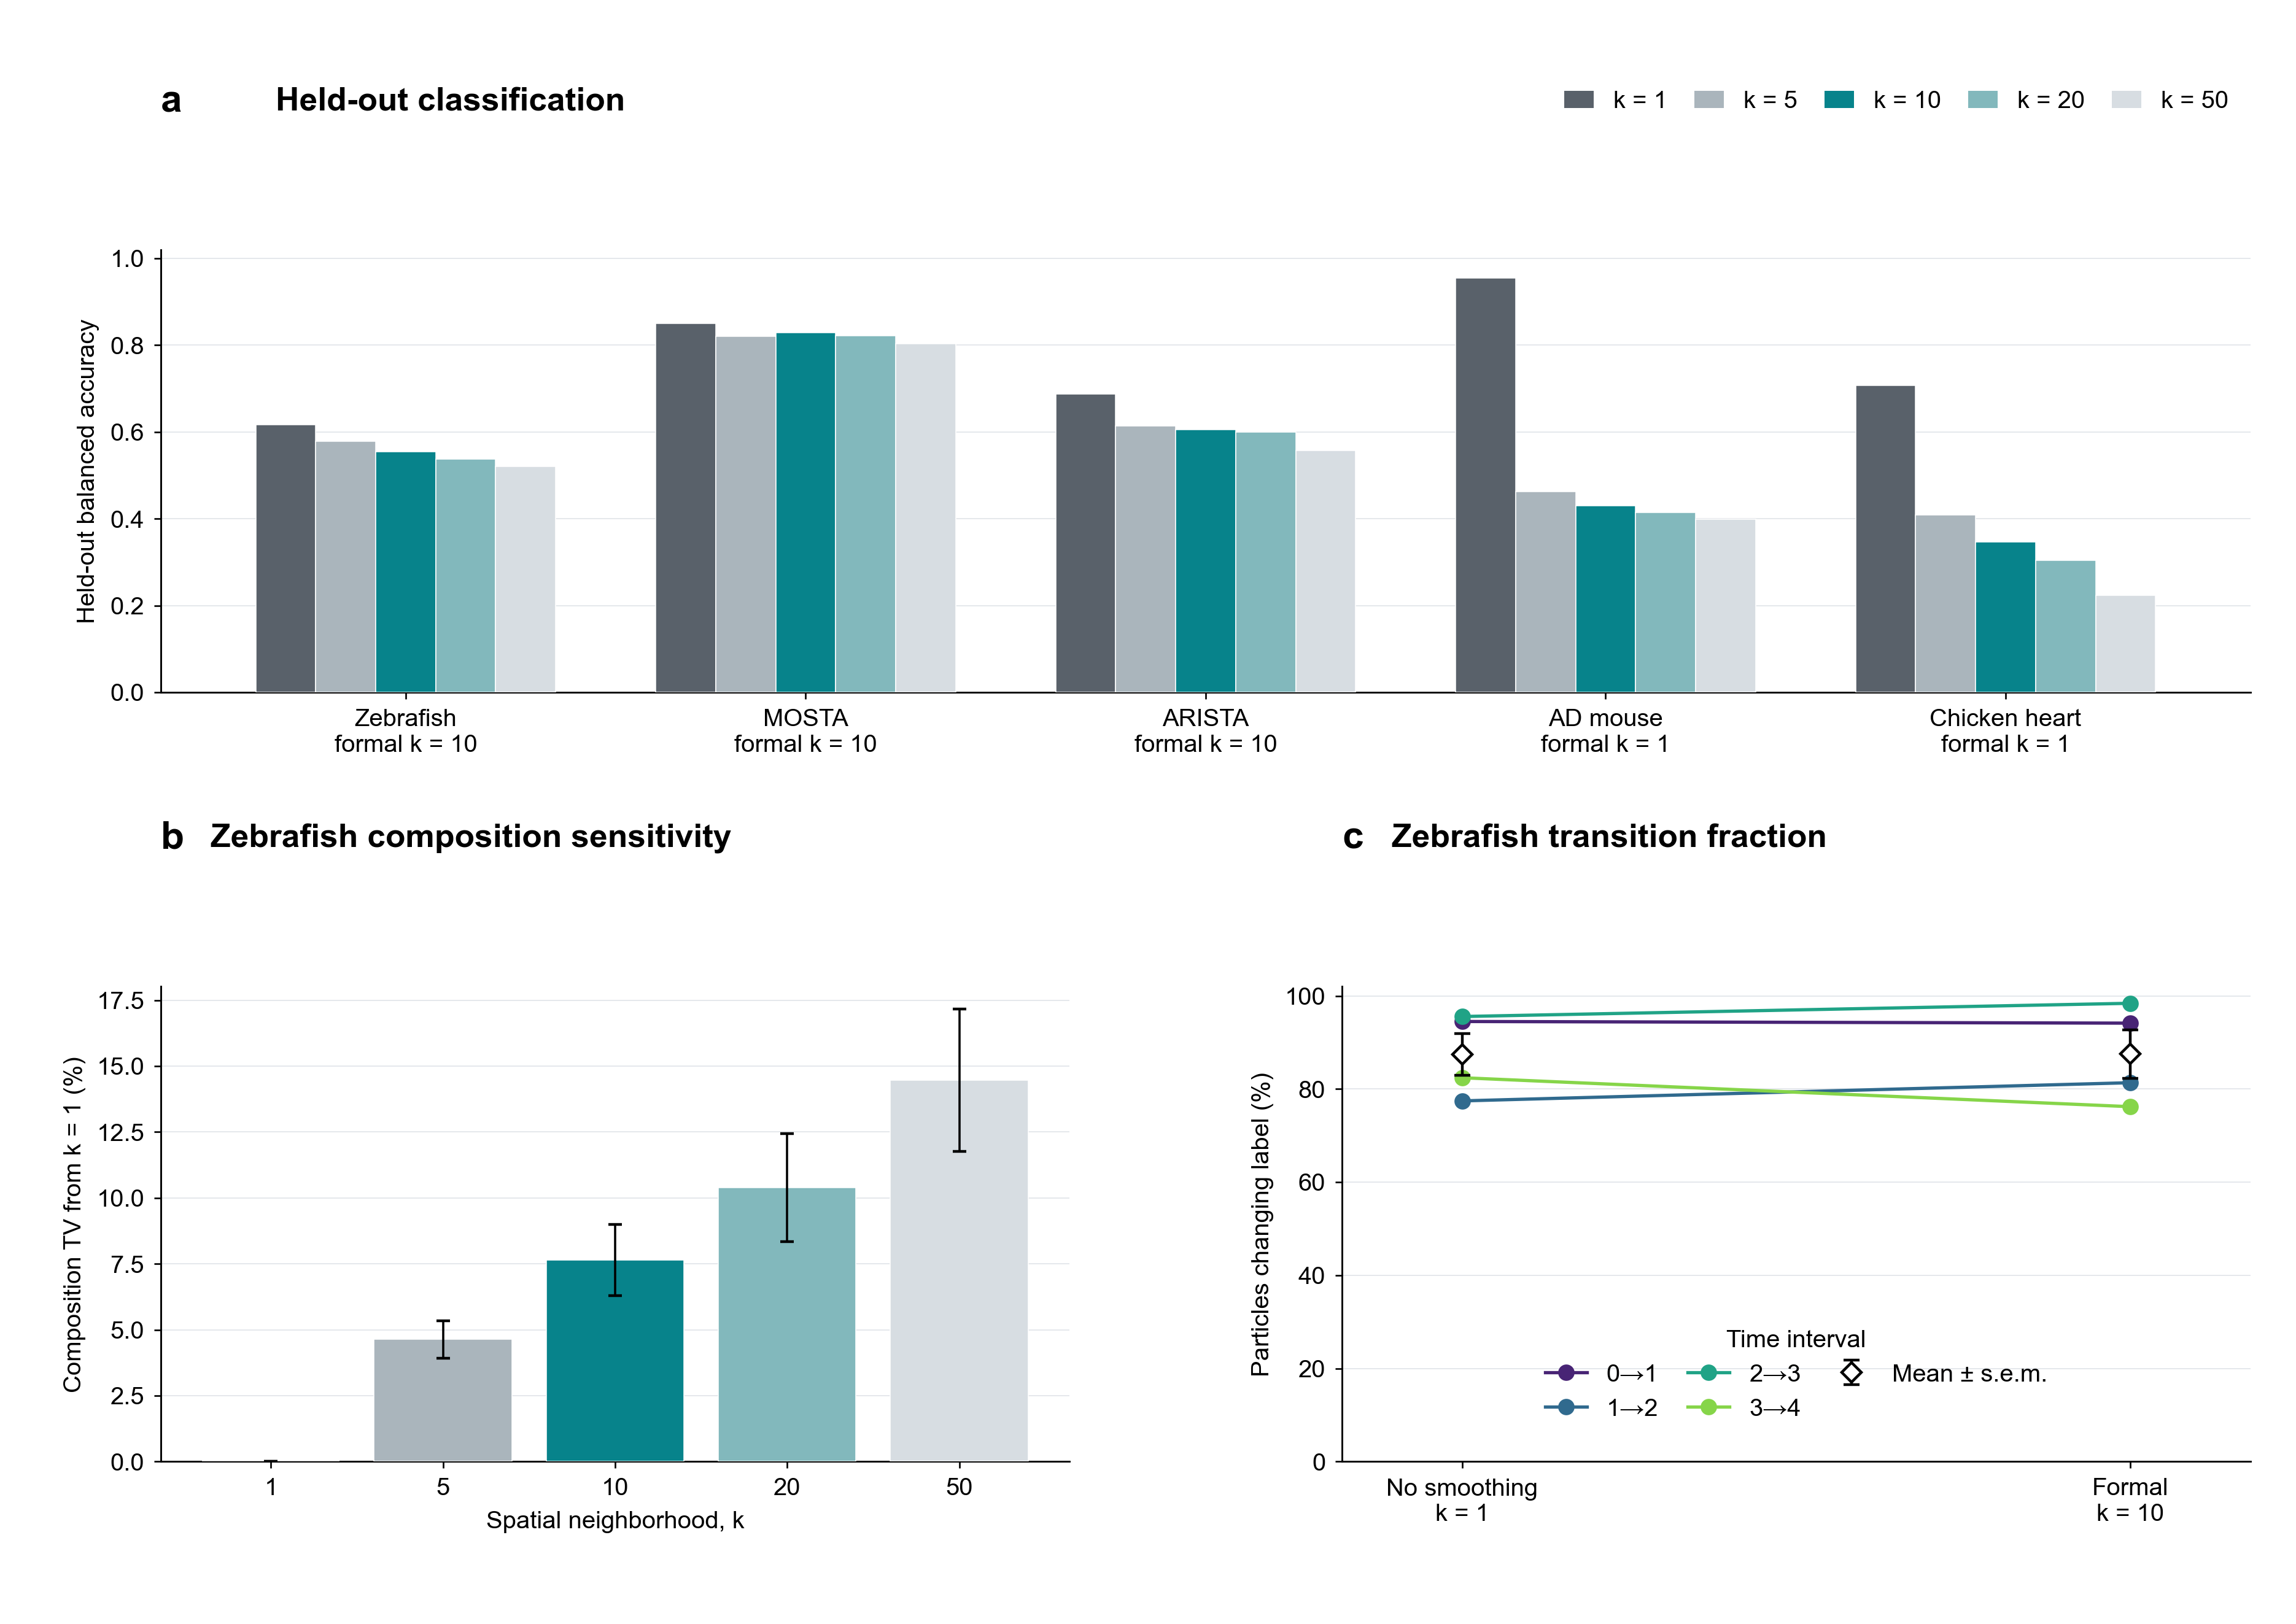

In [4]:
table_paths = write_classifier_smoothing_tables(results, output_dir)
pdf_path, png_path = plot_classifier_smoothing(results, output_dir)
display(Image(filename=str(png_path), width=900))

## Check outputs

In [5]:
{
    "statistics": classifier_smoothing_statistics(results),
    "tables": {name: path.is_file() for name, path in table_paths.items()},
    "pdf": pdf_path.is_file(),
    "png": png_path.is_file(),
}

{'statistics': {'arista_balanced_accuracy_k1': 0.6877649953746441,
  'arista_balanced_accuracy_k10': 0.6054732207227296,
  'chicken_heart_balanced_accuracy_k1': 0.7065001148660296,
  'chicken_heart_balanced_accuracy_k10': 0.3465771733968439,
  'zebrafish_composition_tv_percent_k10': 7.649366770733167,
  'zebrafish_transition_fraction_percent_k1': 87.47779751332149,
  'zebrafish_transition_fraction_percent_k10': 87.52220248667851,
  'zebrafish_transition_percentage_point_delta_k10_vs_k1': 0.04440497335701821},
 'tables': {'metrics': True,
  'policy': True,
  'composition': True,
  'transition': True},
 'pdf': True,
 'png': True}

## Use results from another run

The command-line entry is `scripts/results/plot_classifier_smoothing.py`. The reader API is in `CytoBridge/results/classifier_smoothing.py`. Classifier training and selection are upstream of these processed inputs.